# Train GP mean and kernel

* Supported methods: PAC-PFL ('ours'), pFedGP ('meta_fedavg'), Vanilla ('vanilla').
* For Pooled, MTL, and MAML, please see the baselines folder.

In [1]:
# restart kernel
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

import math, random, pickle, os, copy, itertools, sys, gpytorch
import torch, logging, scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from numpy import random
from datetime import datetime

import matplotlib.pyplot as plt
from collections.abc import Iterable
%matplotlib inline

BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(1, BASE_DIR)

import config
config.init()
from config import device
from utils.utils_pv import visualize_env
from utils.analyze_results import *
from utils.assistive_functions import load_trained_models, softplus_inverse
from utils.pf_scheduler import PriorFactorScheduler
from utils.train_models import train_models
from server.GPR_meta_fedavg import load_serialized_fedavg_model

random_seed = 5
random.seed(random_seed)
np.random.seed(random_seed)
random_state = np.random.RandomState(random_seed)

if torch.cuda.is_available() and not str(device)=='cpu':
    print('[INFO] running on GPU core ' + str(torch.cuda.current_device()))
else:
    print('[WARN] running on CPU')


[INFO] running on GPU core 3


In [2]:
mode = 'ours'            # ours or meta_fedavg or vanilla
exp_name = 'PV_BiModal'         # PV_BiModal, PV_UniModal
scenario_name_fl = 'sml'        # 'sml' or '1y'

save_models = False
train_new = False

verbose = True

if (mode=='vanilla') and not(scenario_name_fl=='sml'):
    assert train_new == False

criteria = ['rsmse', 'calibr', 'nll']
methods = [
    'lingp', 'nn4x2', 'nn16x2', 'nn32x2', 'nn4x4', 'nn64x2', 'nn16x4', 'nn8x4', 'nn4x6',
    'nn32x2_nn4x2', 'nn32x2_nn16x2', 'nn32x2_nn16x4', 'nn32x2_nn32x2', 'nn64x2_nn64x2', 'nn32x2_nn4x4',
    'lingp_nn2x2', 'lingp_nn4x2', 'lingp_nn8x2', 'lingp_nn4x3', 'lingp_nn16x2', 'lingp_nn32x2', #'lingp_nn4x4', # generates nan
    'nn2x2_nn2x2', 'nn2x2_nn4x2',
    'nn4x2_nn4x2', 'nn4x2_nn16x2', 'nn4x2_nn32x2', 'nn4x2_nn4x4',
] 
methods_to_run = [] # load all pre-trained models

# best method for vanilla in bimodal for both sml and 1y is 'lingp_nn2x2'

# Load data
* vary the tilt of the installation and the azimuthal orientation
* same coordinates and altitude of central Lausanne

In [3]:
# ------ LOAD DATA ------
# NOTE: env generated in notebook 1_visualization
filename_env = config.PVDATA_DIR + '/'+ exp_name+"_env"
file = open(filename_env, 'rb')
env_dict = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict['num_clients'])
print(msg)
file.close()
num_clients = env_dict['num_clients'] 
print('\n'+env_dict['info'])

# ----- SELECT A SUBSET OF CLIENTS -----
clients_subset= [12, 14, 15, 17, 22]
print('Subset of clients for demonstration: ', clients_subset)

num_features = len(env_dict['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict['feature_names'])), *env_dict['feature_names'])
    

[INFO] loaded data for 24 clients

24 households at Lausanne Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 
Subset of clients for demonstration:  [12, 14, 15, 17, 22]

[INFO] 15 features:  H_sun T2m WS10m station_irrad_direct_prev lag 1 lag 2 lag 4 lag 18 lag 20 lag 22 lag 43 lag 70 lag 74 lag 121 lag 145


# Step 1: 
### 1.1 fitting the model


In [4]:
# set properties that are different based on the GP mean
options_base={
        # noise setup
        'optimize_noise':True, 
        'noise_std':None, 
        'likelihood_str': 'Gaussian',
        # linear model
        'covar_module_str': ['zero'], 'mean_module_str':['linear'],
        'kernel_nn_layers': [], 'mean_nn_layers':[],
        'nonlinearity_output_m': None, 'nonlinearity_output_k': None,  
        'nonlinearity_hidden_m': None, 'nonlinearity_hidden_k': None,
        'feature_dim':2, 
        'optimize_lengthscale': False, 'lengthscale_fix':[[[0.3,0.3]],], # NOTE
        # Configuration for GP-Prior learning
        'lr': 1e-2,            # initial learning rate for Adam optimizer'
        'lr_decay': 0.90,      # 'multiplicative learning rate decay factor applied after every 1000 steps'
        'task_batch_size': 5,  # number of clients for computing grads'
        'normalize_data': True,
        # iterations
        'num_iter_fit': 5000, # NOTE
        'max_iter_fit': 7000,
        'early_stopping': True,
        'n_threads': 8,
        # time-series prediction
        'ts_data':False
}

# options specific to our method
if mode=='ours':
        options_base['num_particles'] = 4
        options_base['bandwidth'] = -1        # heuristic lengthscale for SVGD heuristically            
        options_base['initial_particles'] = {'noise_raw': softplus_inverse(0.3)}

options = dict.fromkeys(methods)


for method in methods:
        options[method] = copy.deepcopy(options_base)
        # MEAN
        if method.startswith('lingp'):
                options['lingp'].update({'prior_factor':0,}) # data is large enough
        else: # nn means
                if method=='linreg':
                        continue
                assert method.startswith('nn')
                n_nn = method.split('_')[0] # nn4x2, for instance
                num_neurons = int(n_nn.split('x')[0][2:])
                num_layers = int(n_nn.split('x')[-1])
                mean_nn_layers = [(num_neurons, )*num_layers]
                options[method].update({
                        'mean_module_str':['NN'], 'mean_nn_layers':mean_nn_layers,
                        'nonlinearity_hidden_m': [torch.relu, torch.tanh],
                })
        # KERNEL
        if '_' in method:
                # options[method] = copy.deepcopy(options[method.split('_')[0]])
                k_nn = method.split('_')[1] # nn4x2, for instance
                num_neurons = int(k_nn.split('x')[0][2:])
                num_layers = int(k_nn.split('x')[-1])
                kernel_nn_layers = [(num_neurons, )*num_layers]
  
                options[method].update({
                        'covar_module_str':['NN'], 
                        'kernel_nn_layers':kernel_nn_layers,
                        'nonlinearity_hidden_k': torch.tanh#[torch.relu, torch.tanh],
                        })
        else: # use fix noise for all mean models without kernel
                options[method].update({'optimize_noise': False, 'noise_std':0.1})
        # fix noise setup
        if 'fix_noise' in method:
                options[method].update({'optimize_noise': False})
        # hyper-prior:
        if ('fix_noise' in method) or (not mode=='ours'):
                options[method]['hyper_prior_dict'] = {}
        else:
                options[method]['hyper_prior_dict'] = [
                {'noise_raw_loc': softplus_inverse(0.3), 
                        'noise_raw_scale': 0.5},
                {'noise_raw_loc': softplus_inverse(0.3), 
                        'noise_raw_scale': 1},
                {'noise_raw_loc': softplus_inverse(0.3), 
                        'noise_raw_scale': 2},
                ]

        
beta = env_dict['train_scenarios'][scenario_name_fl]['clients_data'][0][0].shape[0]

pf_scheduler_big = PriorFactorScheduler(
        method='grid', 
        num=10, space='log', 
        pf_range=(1e-1, 1),
        test_no_regul=True, init_step_size=None, 
        early_stopping=True, thresh=0.025,
        check_of_any=False # enough not to over-fit on average
        ) if mode=='ours' else None
pf_scheduler_sml = PriorFactorScheduler(
        method='grid', num=6, space='log', 
        pf_range=(0.2, 0.5),
        test_no_regul=False, init_step_size=None, 
        early_stopping=True, thresh=0.025,
        check_of_any=False # enough not to over-fit on average
        ) if mode=='ours' else None


results = dict.fromkeys(methods_to_run)
models = dict.fromkeys(methods_to_run)
# ---------- TRAIN ----------
for method_to_run in methods_to_run:
        if not method_to_run.startswith('resgp'):
                models[method_to_run], results[method_to_run] = train_models(
                        exp_name=exp_name, method_to_run=method_to_run, 
                        mode=mode,
                        env_dict=env_dict, random_seed=random_seed, 
                        criteria='rsmse' if mode=='vanilla' else criteria,
                        options=options, save_models=save_models, 
                        pf_scheduler=None if mode=='vanilla' else pf_scheduler_big,
                        verbose=verbose, clients_subset=None, train_scenarios=scenario_name_fl,
                        file_name=os.path.join(mode+'_' + scenario_name_fl, method_to_run),
                        )


# Select model by min RSMSE on validation set, calculate CE for this model


In [5]:
data_tups = env_dict['train_scenarios'][scenario_name_fl]['clients_data']
models_all = dict.fromkeys(methods_to_run)

for met in methods_to_run:
    if results[met][scenario_name_fl] is None:
        continue

    if mode=='vanilla':
        results[met][scenario_name_fl]['calibr'] = [None] * num_clients # list of dicts
        for client_num in np.arange(num_clients):
            train_data = [(data_tups[client_num][0], data_tups[client_num][1], data_tups[client_num][0], data_tups[client_num][1])] 
            # select model with the lowerst RSMSE on the validation set
            models_all[met] = models[met][scenario_name_fl]['rsmse'][client_num]
            if models_all[met] is None:
                continue
            # reconstruct model
            models_all[met] = load_serialized_fedavg_model(
                [(data_tups[client_num][0], data_tups[client_num][1])], 
                models_all[met]
            )
            # update 
            results[met][scenario_name_fl]['calibr'][client_num] = {
                'criterion_train': models_all[met].eval_datasets(train_data, get_full_list=False)['calibr'], 
                'criterion_valid': models_all[met].eval_datasets([data_tups[client_num]], get_full_list=False)['calibr'],
            }
    elif mode =='meta_fedavg':
        train_data = [(d[0], d[1], d[0], d[1]) for d in data_tups]
        models_all[met] = models[met][scenario_name_fl]['rsmse']
        if models_all[met] is None:
            continue
        # reconstruct model
        models_all[met] = load_serialized_fedavg_model(
            [(d[0], d[1]) for d in data_tups], 
            models_all[met]
        )
        results[met][scenario_name_fl]['calibr'] = {
            'criterion_train': models_all[met].eval_datasets(train_data, get_full_list=True)['calibr'], 
            'criterion_valid': models_all[met].eval_datasets(data_tups, get_full_list=True)['calibr'],
        }



In [6]:
# only to get results for different random seeds
print('--- results with random seed = {:2.0f} in '.format(random_seed), scenario_name_fl, ' ---')
if len(methods_to_run)>0:
    for criterion in ['rsmse', 'calibr']:
        if mode=='vanilla':
            r = []
            for client_res in results[methods_to_run[0]][scenario_name_fl][criterion]:
                if not client_res is None:
                    r.append(client_res['criterion_valid'])
        else:
            r = results[methods_to_run[0]][scenario_name_fl][criterion]['criterion_valid']
        print('\n ' + scenario_name_fl + ' - ' + criterion + ': ', np.mean(np.array(r)))



--- results with random seed =  5 in  sml  ---


# Step 2: Analysis
### 2.1 Box Plots

In [7]:
run_analysis = True

In [8]:
if run_analysis:
    clients_train_data = None
    if mode in ['vanilla', 'meta_fedavg']:
        clients_train_data = []
        for d in env_dict['train_scenarios'][scenario_name_fl]['clients_data']:
            clients_train_data.append((d[0], d[1]))

    # ---------- Load Trained Models ----------
    filename_res = os.path.join(os.getcwd(), "saved_results", exp_name, mode)
    models_all, results_all = load_trained_models(
        mode=mode, methods=None, ts_data=False,
        filename_res=filename_res+'_'+scenario_name_fl,
        clients_train_data=clients_train_data)


    # ----------       BOX PLOTS      ----------
    #perf_box_plots(env_dict, criterion='nll', methods=methods, results_all=results_all)



[INFO] results of method resgp_nn16x4_nn16 loaded.

[INFO] results of method resgp_nn16x4_nn16_fixnoise2 loaded.

[INFO] results of method resgp_nn16x4_nn32_fixnoise4 loaded.

[INFO] results of method nn32_nn16x4 loaded.

[INFO] results of method resgp_nn16x4_nn32 loaded.

[INFO] results of method lingp loaded.

[INFO] results of method resgp_nn32_nn16 loaded.

[INFO] results of method resgp_nn16x4_nn16_fixnoise6 loaded.

[INFO] results of method resgp_nn16x4_nn16_fixnoise4 loaded.

[INFO] results of method nn32_nn16 loaded.

[INFO] results of method resgp_nn16x4_nn16_fixnoise8 loaded.

[INFO] results of method nn64_nn64 loaded.


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274


[WARNING] The input matches the stored training data. Did you forget to call model.train()? GPInputWarning
in file/home/mahrokhg/anaconda3/envs/python3/lib/python3.10/site-packages/gpytorch/models/exact_gp.py at line number:274

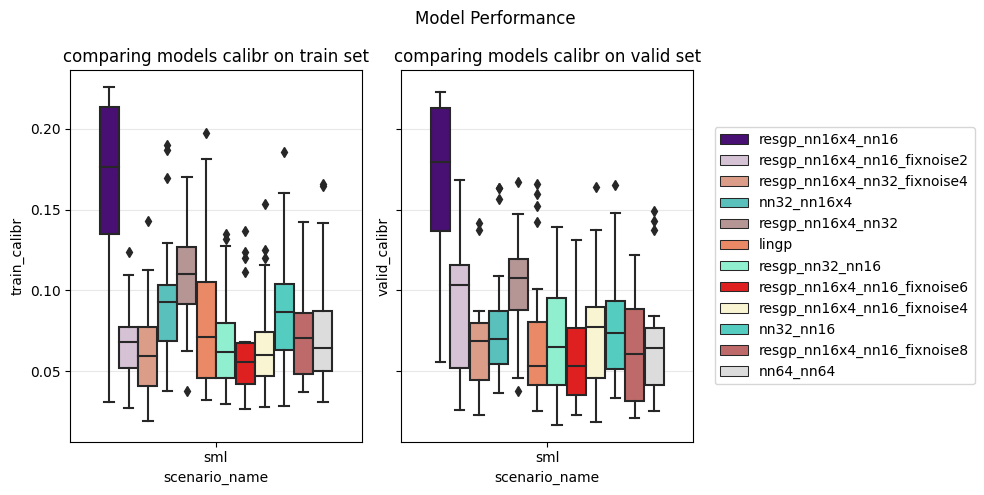

                         method scenario_name  valid_calibr_mean  \
0                         lingp           sml           0.069531   
1                     nn32_nn16           sml           0.079225   
2                   nn32_nn16x4           sml           0.078847   
3                     nn64_nn64           sml           0.066355   
4             resgp_nn16x4_nn16           sml           0.166060   
5   resgp_nn16x4_nn16_fixnoise2           sml           0.092597   
6   resgp_nn16x4_nn16_fixnoise4           sml           0.072181   
7   resgp_nn16x4_nn16_fixnoise6           sml           0.059830   
8   resgp_nn16x4_nn16_fixnoise8           sml           0.062755   
9             resgp_nn16x4_nn32           sml           0.102525   
10  resgp_nn16x4_nn32_fixnoise4           sml           0.065344   
11              resgp_nn32_nn16           sml           0.067794   

    valid_calibr_min  valid_calibr_max  valid_calibr_median  
0           0.025529          0.165570             0.

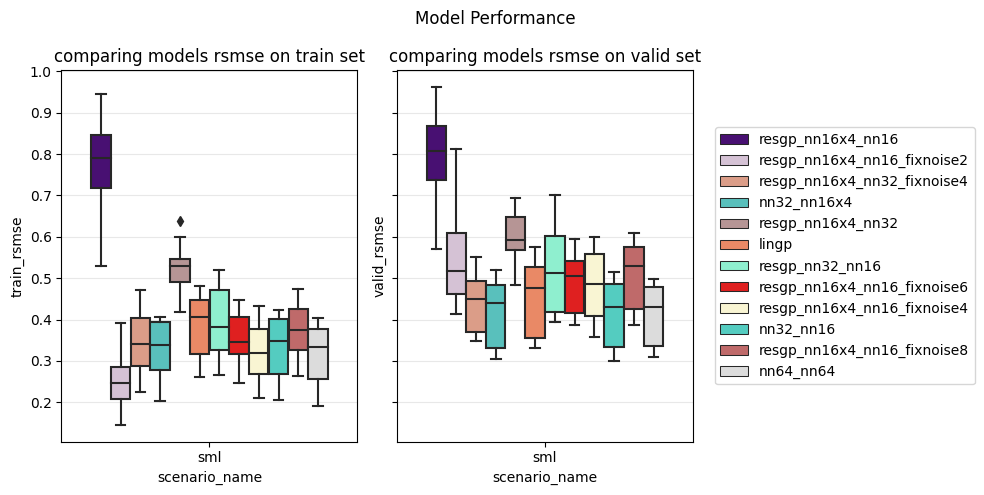

                         method scenario_name  valid_rsmse_mean  \
0                         lingp           sml          0.449275   
1                     nn32_nn16           sml          0.414021   
2                   nn32_nn16x4           sml          0.414264   
3                     nn64_nn64           sml          0.411540   
4             resgp_nn16x4_nn16           sml          0.804502   
5   resgp_nn16x4_nn16_fixnoise2           sml          0.549437   
6   resgp_nn16x4_nn16_fixnoise4           sml          0.484492   
7   resgp_nn16x4_nn16_fixnoise6           sml          0.484087   
8   resgp_nn16x4_nn16_fixnoise8           sml          0.504076   
9             resgp_nn16x4_nn32           sml          0.607439   
10  resgp_nn16x4_nn32_fixnoise4           sml          0.437997   
11              resgp_nn32_nn16           sml          0.519075   

    valid_rsmse_min  valid_rsmse_max  valid_rsmse_median  
0          0.331184         0.575438            0.475751  
1         

In [9]:
if run_analysis:
    if mode=='vanilla':
        data_tups = env_dict['train_scenarios'][scenario_name_fl]['clients_data']
        for met in results_all.keys():
            if results_all[met] is None:
                continue
            if results_all[met][scenario_name_fl] is None:
                continue
            results_all[met][scenario_name_fl]['calibr'] = [None] * num_clients # list of dicts
            for client_num in np.arange(num_clients):
                train_data = [(data_tups[client_num][0], data_tups[client_num][1], data_tups[client_num][0], data_tups[client_num][1])] 

                # select model with the lowerst RSMSE on the validation set
                model = models_all[met][scenario_name_fl]['rsmse'][client_num]
                if model is None:
                    continue
                # update 
                results_all[met][scenario_name_fl]['calibr'][client_num] = {
                    'criterion_train': model.eval_datasets(train_data, get_full_list=False)['calibr'], 
                    'criterion_valid': model.eval_datasets([data_tups[client_num]], get_full_list=False)['calibr'],
                }

    else:
        for met in results_all.keys():
            if results_all[met] is None:
                continue
            # update calibration
            models_all[met] = models_all[met][scenario_name_fl]['rsmse']
            data_tups = env_dict['train_scenarios'][scenario_name_fl]['clients_data']
            # update train
            train_data = [(d[0], d[1], d[0], d[1]) for d in data_tups]
            res_train = models_all[met].eval_datasets(train_data, get_full_list=True)
            res_valid = models_all[met].eval_datasets(data_tups, get_full_list=True)
            results_all[met][scenario_name_fl] = {
                'rsmse': {'criterion_train':res_train['rsmse'], 'criterion_valid':res_valid['rsmse']},
                'calibr': {'criterion_train':res_train['calibr'], 'criterion_valid':res_valid['calibr']}
            }



    stats_df = perf_box_plots(env_dict, criterion='calibr', methods=results_all.keys(), results_all=results_all)
    print(stats_df)

    stats_df = perf_box_plots(env_dict, criterion='rsmse', methods=results_all.keys(), results_all=results_all)
    print(stats_df)


## 3. New Clients for vanilla and pFedGP ('meta_fedavg')

In [30]:
exp_name_ptc = exp_name
exp_name_new = exp_name_ptc + '_NewClients'
assert not mode=='ours', 'Please run new_clients.ipynb for evaluating PAC-PFL on new clients'

# ----- SET UP LOGGER -----
filename_env_new = config.PVDATA_DIR + '/'+ exp_name_ptc +"_new_clients_env"
filename_res_new = os.path.join(os.getcwd(), "saved_results", exp_name_new)


# ------ LOAD META_TEST DATA ------
file = open(filename_env_new, 'rb')
env_dict_new = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict_new['num_clients'])
print(msg)
file.close()
num_clients_new = env_dict_new['num_clients'] 
print('\n'+env_dict_new['info'])



for scenario_name in env_dict_new['train_scenarios'].keys():
    print(scenario_name + ' has {:3.0f} train and {:3.0f} validation samples'.format(
        env_dict_new['train_scenarios'][scenario_name]['clients_data'][0][0].shape[0],
        env_dict_new['train_scenarios'][scenario_name]['clients_data'][0][2].shape[0]))
num_features = len(env_dict_new['feature_names'])
print('\n[INFO] {:2.0f} features: '.format(
    len(env_dict_new['feature_names'])), *env_dict_new['feature_names'])

# visualize_env(env_dict_new, num_days=5, year=2018, scenario_name='1y')


AssertionError: Please run new_clients.ipynb for evaluating PAC-PFL on new clients

In [23]:
if mode=='ours':
    best_met = 'resgp_nn32_nn16'
elif mode=='meta_fedavg':
    best_met = 'lingp_nn4x2' if scenario_name_fl=='sml' else 'lingp_nn8x2'
if mode == 'vanilla':
    best_met = 'lingp_nn2x2'
    file_name=os.path.join(mode+'_' + scenario_name_fl, best_met+'_new_clients')
    if train_new:
        models_new, results_new = train_models(
            exp_name=exp_name_new, method_to_run=best_met, 
            mode=mode,
            env_dict=env_dict_new, random_seed=random_seed, 
            criteria=criteria,
            options=options, save_models=save_models, pf_scheduler=None,
            verbose=verbose, clients_subset=None, train_scenarios='sml', # NOTE: new clients have small
            file_name=file_name,
            )
        # models_new and results_new are only for the best method in sml scenario
    else:
        models_new, results_new = load_trained_models(
            mode=mode, methods=[best_met], ts_data=False,
            filename_res=file_name,
            clients_train_data=[(d[0], d[1]) for d in env_dict_new['train_scenarios']['sml']['clients_data']])
elif mode in ['meta_fedavg', 'ours']:
    #if mode == 'ours':
    model = models_all[best_met]
    clients_data = env_dict_new['train_scenarios']['sml']['clients_data'] # IMPORTANT: small data of new
    results_new = model.eval_datasets(clients_data, flatten_y=True, get_full_list=True)
    # test_rsmses_new = np.zeros(num_clients_new)
    # for client_num in np.arange(num_clients_new):


In [24]:
# compute CE for the model with min RSMSE. only needed for Vanilla
if mode=='vanilla' and scenario_name_fl=='sml':
    data_tups = env_dict_new['train_scenarios']['sml']['clients_data']
    results_new['calibr'] = np.zeros(num_clients_new) 
    for client_num in np.arange(num_clients_new):
        # select model with the lowerst RSMSE on the validation set
        model = models_new['sml']['rsmse'][client_num]
        if model is None:
            continue
        # reconstruct model
        model = load_serialized_fedavg_model(
            [(data_tups[client_num][0], data_tups[client_num][1])], 
            model
        )
        # update         
        results_new['calibr'][client_num] =  model.eval_datasets([data_tups[client_num]], get_full_list=False)['calibr']


In [28]:
# only to get results for different random seeds
print('--- results with random seed = {:2.0f} in '.format(random_seed), scenario_name_fl, ' ---')
for exs_new, res in zip(['existing', 'new'], [results_all[best_met][scenario_name_fl], results_new]):
    for criterion in ['rsmse', 'calibr']:
        if mode=='vanilla':
            r = []
            for client_res in res[criterion]:
                if not client_res is None:
                    if isinstance(client_res, dict):
                        r.append(client_res['criterion_valid'])
                    else:
                        r.append(client_res)
        else:
            r = res[criterion]
            r = r['criterion_valid'] if isinstance(r, dict) else r
        print('\n' + exs_new + ' - ' + criterion + ': ', np.mean(np.array(r)))




--- results with random seed =  5 in  sml  ---

existing - rsmse:  0.5190748775473414

existing - calibr:  0.0677937944419682

new - rsmse:  0.5209822642087386

new - calibr:  0.06937439398219188


In [ ]:
# Vanilla results with different seeds
# Bimodal - sml with lingp_nn2x2
# exs - RSMSE: [0.6403155475320029,  0.6363081912943481 , 0.6204200499844323 , 0.5954789892830538 , 0.6362324126926437]
# exs - Calib: [0.11622219967345397, 0.12480307246247928, 0.11146703734993935, 0.12119248074789842, 0.1275561119740208]
# new - RSMSE: [0.6399062692670013,  0.6174713556198916,  0.5967552743152641 , 0.6788008822883421 , 0.6295019629819261]
# new - Calib: [0.11868375974396865, 0.11774278028557698, 0.11326309852302074, 0.12737736509492   , 0.12522167712450027]

# Bimodal - 1y with lingp_nn2x2
# exs - RSMSE: [, 0.4449974218958301, 0.4660284416573466, 0.46124214624141596, 0.45841921361010723]
# exs - Calib: [, 0.028313451951059204, 0.027854089625179768, 0.02796577095674972, 0.02737758254321913]

# ------------------------------
# Unimodal - sml with lingp_nn2x2
# exs - RSMSE: [0.6844764254616477, 0.6845826182292322, 0.7030020269052558, 0.6736994863486355, 0.6667825642591451]
# exs - Calib: [0.12279042756805818, 0.11905702482908964, 0.11683127128829558, 0.12869775791962942, 0.12461109086871147]
# new - RSMSE: []
# new - Calib: []

# Unimodal - 1y with lingp_nn2x2
# exs - RSMSE: [0.4658326639267922, 0.4759672222787305, 0.516660350107142, 0.5134580705817846, 0.4687592236846341]
# exs - Calib: [0.036593456442157425, 0.03662862256169319, 0.03475814211803178, 0.03803799898984531, 0.03554370153384904]




# pFedGP results with different seeds
# Bimodal - 1y - lingp_nn8x2
# exs - RSMSE:  [0.45325241678251177, 0.45535842562337914, 0.4487886339865925, 0.46626263354334424, 0.4599310747668343]
# exs - Calibr: [0.05092752034155031, 0.05433564664175113, 0.04518240635904173, 0.053703667828813195, 0.05383524352995058]
# new - RSMSE:  [0.45251225013057156, 0.4588500229544931,  0.4470228485689196, 0.46332061781829886, 0.46227670899624984]
# new - Calib:  [0.051867247403909765, 0.06080009431267778, 0.05030741604665915, 0.05956206672514478, 0.05614174894678096]

# Unimodal - 1y - lingp_nn8x2
# exs - RSMSE:  [0.5106594152361242, 0.4907072531733215, 0.50178575550302, 0.536549076528028, 0.5303591730009947]
# exs - Calibr: [0.06583126820623875, 0.06450115625436108, 0.06794270686805248, 0.06623583473265171, 0.06537319634420176]
# new - RSMSE:  [0.4931702701239227, 0.48975586522857, 0.4946674223904101, 0.5270853098682323, 0.559104146309152]
# new - Calib:  [0.07012328947894275, 0.06068613073633363, 0.06453928351402283, 0.061320908910905324, 0.06535315971511106]

# Bimodal - sml - lingp_nn4x2
# exs - RSMSE:  [0.45698283478167623, 0.45041833678279697, 0.46224844522451686, 0.4447097499669652, 0.4448590077822554]
# exs - Calibr: [0.0591870112499843, 0.05937387483815352, 0.05149973277002573, 0.05733007378876209, 0.05878561409190297]
# new - RSMSE:  [0.4490121801552908, 0.4472314710552167, 0.46153227189382623, 0.440355374745596, 0.43554978139756456]
# new - Calib:  [0.06272289669141173, 0.059290177964915834, 0.05754189953828851, 0.05782253590101997, 0.06735315003121893]

# Unimodal - sml - lingp_nn4x2
# exs - RSMSE:  [0.4638428139141251, 0.4750934583932473, 0.45337482917275707, 0.506872258494696, 0.4933290972810768]
# exs - Calibr: [0.07600374116251866, 0.051308203022927046, 0.07790796474243204, 0.07198314694687724, 0.059146291304690145]
# new - RSMSE:  [0.4610822900497144, 0.4486784538281016, 0.4393395263005635, 0.5007225840658993, 0.4717627437534848]
# new - Calib:  [0.07630054869999488, 0.057699635702495776, 0.07309582449185352, 0.07528835178042452, 0.06288399702558915]



0.069, 0.015
